# L3: Agentic Sales Pipeline

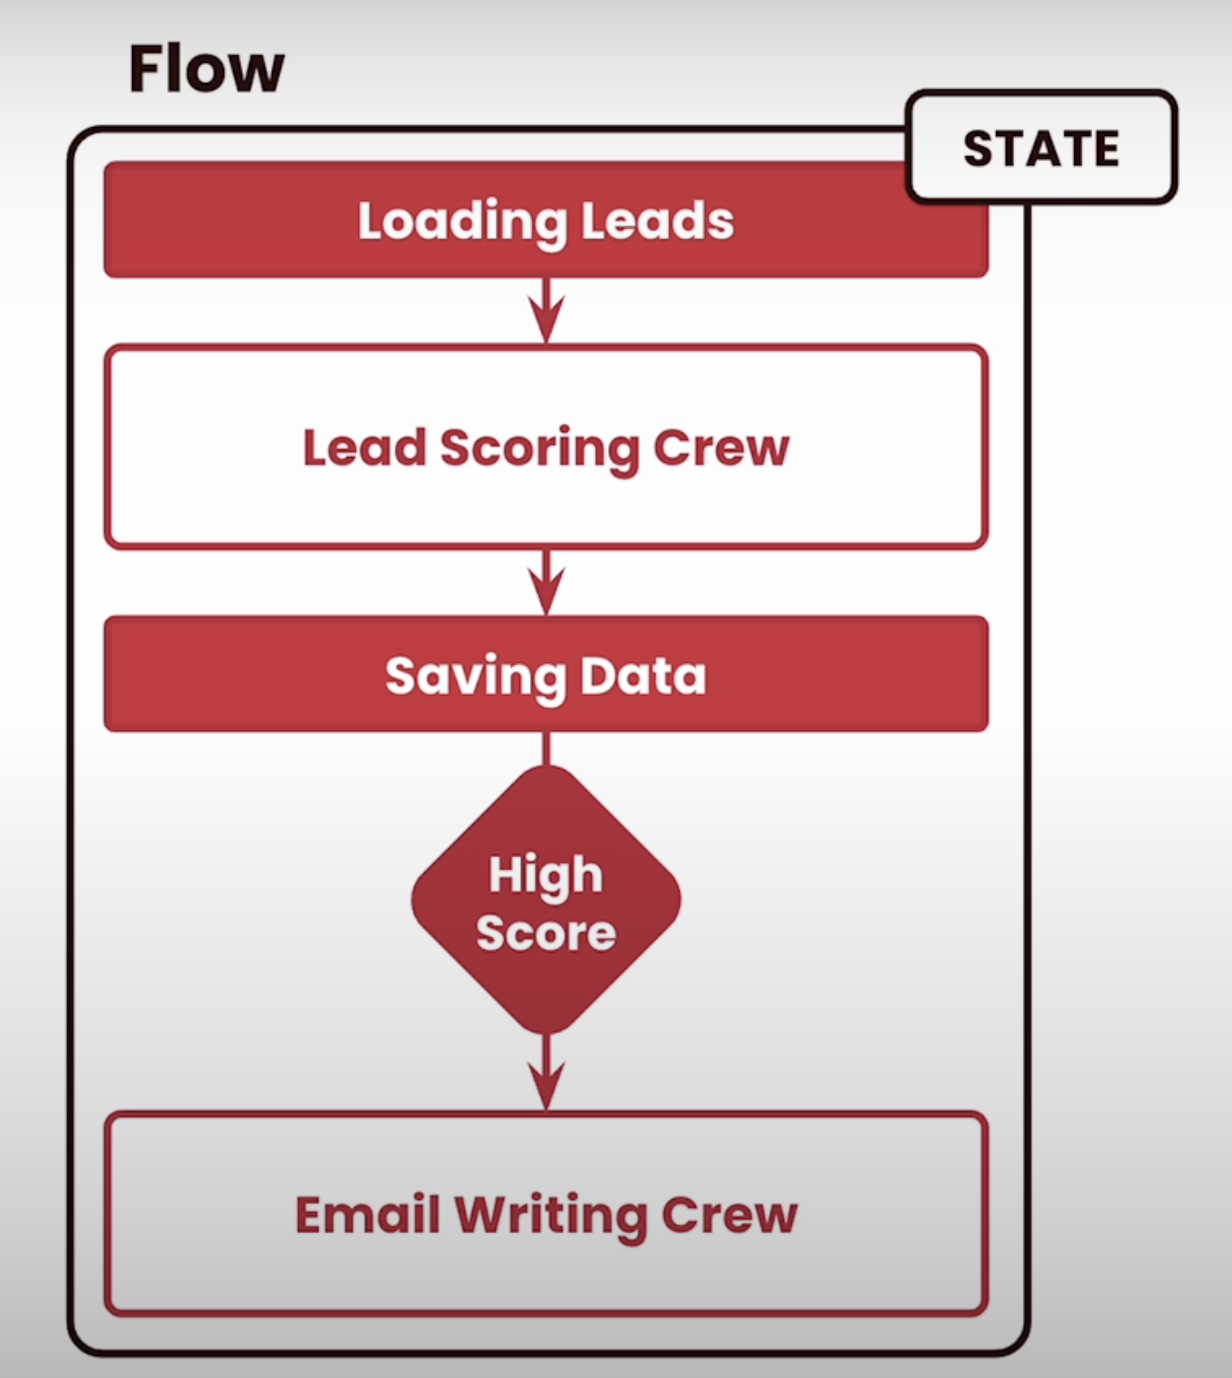
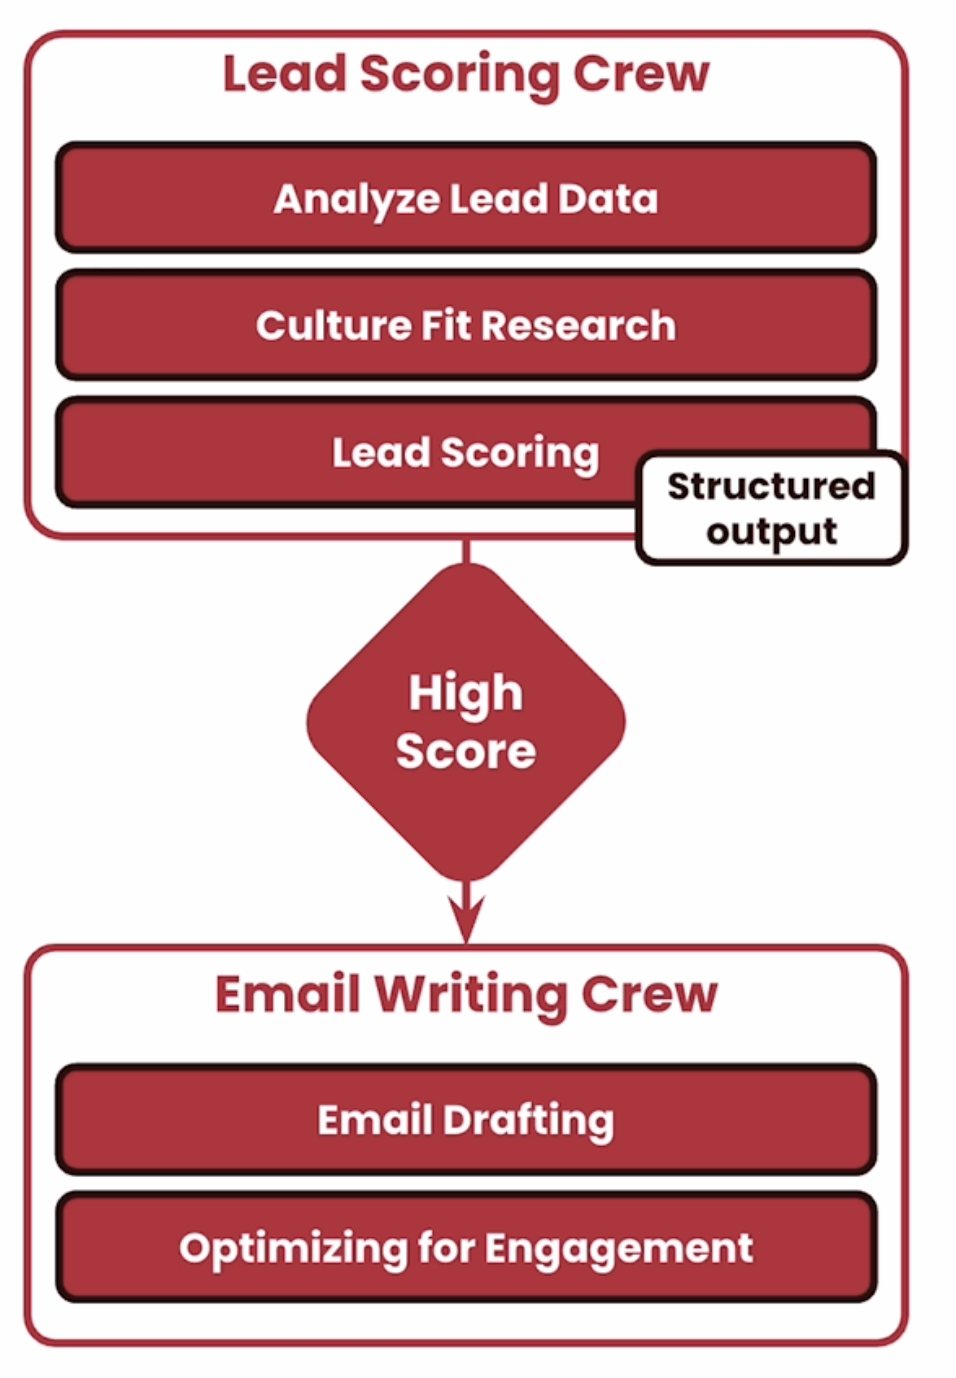

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

## Initial Imports

In [6]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
from helper import load_env
load_env()

import os
import yaml
from crewai import Agent, Task, Crew

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

## Load API tokens for our 3rd party APIs

In [7]:
os.environ['OPENAI_MODEL_NAME'] = 'gpt-4o-mini'

## Loading Tasks and Agents YAML files

In [8]:
# Define file paths for YAML configurations
files = {
    'lead_agents': 'config/lead_qualification_agents.yaml',
    'lead_tasks': 'config/lead_qualification_tasks.yaml',
    'email_agents': 'config/email_engagement_agents.yaml',
    'email_tasks': 'config/email_engagement_tasks.yaml'
}

# Load configurations from YAML files
configs = {}
for config_type, file_path in files.items():
    with open(file_path, 'r') as file:
        configs[config_type] = yaml.safe_load(file)

# Assign loaded configurations to specific variables
lead_agents_config = configs['lead_agents']
lead_tasks_config = configs['lead_tasks']
email_agents_config = configs['email_agents']
email_tasks_config = configs['email_tasks']

## Create Pydantic Models for Structured Output

In [9]:
from pydantic import BaseModel, Field
from typing import Dict, Optional, List, Set, Tuple

class LeadPersonalInfo(BaseModel):
    name: str = Field(..., description="The full name of the lead.")
    job_title: str = Field(..., description="The job title of the lead.")
    role_relevance: int = Field(..., ge=0, le=10, description="A score representing how relevant the lead's role is to the decision-making process (0-10).")
    professional_background: Optional[str] = Field(..., description="A brief description of the lead's professional background.")

class CompanyInfo(BaseModel):
    company_name: str = Field(..., description="The name of the company the lead works for.")
    industry: str = Field(..., description="The industry in which the company operates.")
    company_size: int = Field(..., description="The size of the company in terms of employee count.")
    revenue: Optional[float] = Field(None, description="The annual revenue of the company, if available.")
    market_presence: int = Field(..., ge=0, le=10, description="A score representing the company's market presence (0-10).")

class LeadScore(BaseModel):
    score: int = Field(..., ge=0, le=100, description="The final score assigned to the lead (0-100).")
    scoring_criteria: List[str] = Field(..., description="The criteria used to determine the lead's score.")
    validation_notes: Optional[str] = Field(None, description="Any notes regarding the validation of the lead score.")

class LeadScoringResult(BaseModel):
    personal_info: LeadPersonalInfo = Field(..., description="Personal information about the lead.")
    company_info: CompanyInfo = Field(..., description="Information about the lead's company.")
    lead_score: LeadScore = Field(..., description="The calculated score and related information for the lead.")

## Importing Tools

In [10]:
from crewai_tools import SerperDevTool, ScrapeWebsiteTool

## Lead Qualification Crew, Agents and Tasks

In [11]:
# Creating Agents
lead_data_agent = Agent(
  config=lead_agents_config['lead_data_agent'],
  tools=[SerperDevTool(), ScrapeWebsiteTool()]
)

cultural_fit_agent = Agent(
  config=lead_agents_config['cultural_fit_agent'],
  tools=[SerperDevTool(), ScrapeWebsiteTool()]
)

scoring_validation_agent = Agent(
  config=lead_agents_config['scoring_validation_agent'],
  tools=[SerperDevTool(), ScrapeWebsiteTool()]
)

# Creating Tasks
lead_data_task = Task(
  config=lead_tasks_config['lead_data_collection'],
  agent=lead_data_agent
)

cultural_fit_task = Task(
  config=lead_tasks_config['cultural_fit_analysis'],
  agent=cultural_fit_agent
)

scoring_validation_task = Task(
  config=lead_tasks_config['lead_scoring_and_validation'],
  agent=scoring_validation_agent,
  context=[lead_data_task, cultural_fit_task],
  output_pydantic=LeadScoringResult
)

# Creating Crew
lead_scoring_crew = Crew(
  agents=[
    lead_data_agent,
    cultural_fit_agent,
    scoring_validation_agent
  ],
  tasks=[
    lead_data_task,
    cultural_fit_task,
    scoring_validation_task
  ],
  verbose=True
)

## Email Engagement Crew

In [12]:
# Creating Agents
email_content_specialist = Agent(
  config=email_agents_config['email_content_specialist']
)

engagement_strategist = Agent(
  config=email_agents_config['engagement_strategist']
)

# Creating Tasks
email_drafting = Task(
  config=email_tasks_config['email_drafting'],
  agent=email_content_specialist
)

engagement_optimization = Task(
  config=email_tasks_config['engagement_optimization'],
  agent=engagement_strategist
)

# Creating Crew
email_writing_crew = Crew(
  agents=[
    email_content_specialist,
    engagement_strategist
  ],
  tasks=[
    email_drafting,
    engagement_optimization
  ],
  verbose=True
)

2025-02-15 14:23:48,932 - 140178126953344 - __init__.py-__init__:538 - WARNING: Overriding of current TracerProvider is not allowed


## Creating Complete Sales Flow

In [13]:
from crewai import Flow
from crewai.flow.flow import listen, start

class SalesPipeline(Flow):
    @start()
    def fetch_leads(self):
        # Pull our leads from the database
        leads = [
            {
                "lead_data": {
                    "name": "João Moura",
                    "job_title": "Director of Engineering",
                    "company": "Clearbit",
                    "email": "joao@clearbit.com",
                    "use_case": "Using AI Agent to do better data enrichment."
                },
            },
        ]
        return leads

    @listen(fetch_leads)
    def score_leads(self, leads):
        scores = lead_scoring_crew.kickoff_for_each(leads)
        self.state["score_crews_results"] = scores
        return scores

    @listen(score_leads)
    def store_leads_score(self, scores):
        # Here we would store the scores in the database
        return scores

    @listen(score_leads)
    def filter_leads(self, scores):
        return [score for score in scores if score['lead_score'].score > 70]

    @listen(filter_leads)
    def write_email(self, leads):
        scored_leads = [lead.to_dict() for lead in leads]
        emails = email_writing_crew.kickoff_for_each(scored_leads)
        return emails

    @listen(write_email)
    def send_email(self, emails):
        # Here we would send the emails to the leads
        return emails

flow = SalesPipeline()

## Plotting the Flow

In [14]:
flow.plot()

Graph saved as crewai_flow_graph.html


In [15]:
from IPython.display import IFrame

IFrame(src='./crewai_flow.html', width='150%', height=600)

## Flow Kickoff

In [16]:
emails = await flow.kickoff()

2025-02-15 14:23:50,780 - 140178126953344 - __init__.py-__init__:538 - WARNING: Overriding of current TracerProvider is not allowed


# Agent: Lead Data Specialist
## Task: Collect and analyze the following information about the lead:
- Personal Information:
  - Name: Obtain the full name of the lead.
  - Job Title: Determine the lead's current job title.
  - Role Relevance: Assess how relevant the lead's role is to the decision-making process on a scale from 0 to 10.
  - Professional Background: Optionally, gather a brief description of the lead's professional background.

- Company Information:
  - Company Name: Identify the name of the company the lead works for.
  - Industry: Determine the industry in which the company operates.
  - Company Size: Estimate the size of the company in terms of employee count.
  - Revenue: If available, collect information on the annual revenue of the company.
  - Market Presence: Evaluate the company's market presence on a scale from 0 to 10.

- Our Company and Product:
  - Company Name: CrewAI
  - Product: Multi-Agent Orchestration Platform
  - ICP: Enterprise companies looking int



# Agent: Lead Data Specialist
## Thought: Thought: I've gathered substantial information about João Moura's professional background, including his leadership at Clearbit and previous experience. Now, I will need to find information about Clearbit itself to gather data regarding the company, including its industry, size, revenue, and market presence.
## Using tool: Search the internet
## Tool Input: 
"{\"search_query\": \"Clearbit company profile industry size revenue\"}"
## Tool Output: 

Search results: Title: Clearbit 2025 Company Profile: Valuation, Investors, Acquisition
Link: https://pitchbook.com/profiles/company/101066-86
Snippet: What is the size of Clearbit? Clearbit has 116 total employees. What industry is Clearbit in? Clearbit's primary industry is Business/Productivity Software.
---
Title: Leverage 100+ business data attributes - Clearbit
Link: https://clearbit.com/attributes
Snippet: Enrich your CRM and database, manage leads efficiently, and enable marketing personaliz



# Agent: Cultural Fit Analyst
## Thought: Thought: The website content did not provide specific information on Clearbit's cultural values, mission, or strategic goals. I need to conduct a broader internet search to find relevant insights on Clearbit's culture and values.
## Using tool: Search the internet
## Tool Input: 
"{\"search_query\": \"Clearbit company culture values mission statement\"}"
## Tool Output: 

Search results: Title: Defining Clearbit's company values
Link: https://clearbit.com/blog/company-values
Snippet: Surfacing values, from the bottom up · being customer centric / empathy for customers · learning · excellence / hard work · self-sufficiency · fun ...
---
Title: Mission, Vision & Core Values of Clearbit – CBM
Link: https://canvasbusinessmodel.com/blogs/mission/clearbit-mission?srsltid=AfmBOopBOdSEuFAYpYh581mKyN08u6YiFzzPjUQZLJ6HjrA9HNXxQfQt
Snippet: At Clearbit, our mission is to empower companies with actionable business intelligence to make informed decisions 



# Agent: Cultural Fit Analyst
## Thought: Thought: I have gathered information about Clearbit's values from their blog. I'll summarize the extracted cultural values and assess them against CrewAI's values and strategic objectives. Additionally, I must find their mission statement to understand their strategic alignment fully.
## Using tool: Read website content
## Tool Input: 
"{\"website_url\": \"https://canvasbusinessmodel.com/blogs/mission/clearbit-mission?srsltid=AfmBOopBOdSEuFAYpYh581mKyN08u6YiFzzPjUQZLJ6HjrA9HNXxQfQt\"}"
## Tool Output: 
Mission, Vision & Core Values of Clearbit – CANVAS, SWOT, PESTEL & BCG Matrix Editable Templates for Startups
Skip to content
Framework Templates
Blogs
Search
Cart
0
/
$0.00
 EN
EN
ES
FR
PT
Mission, Vision & Core Values of ClearbitOctober 2, 2024
CLEARBIT BUNDLE
Get Full Bundle:
Porter's Five Forces
$15
$10
BCG Matrix
$15
$10
Canvas
$15
$10
Marketing Mix
$15
$10
PESTLE Analysis
$15
$10
SWOT Analysis
$15
$10
TOTAL: ADD SELECTED TO CART 
At Clear

 Error parsing LLM output, agent will retry: I did it wrong. Invalid Format: I missed the 'Action:' after 'Thought:'. I will do right next, and don't use a tool I have already used.

If you don't need to use any more tools, you must give your best complete final answer, make sure it satisfy the expect criteria, use the EXACT format below:

Thought: I now can give a great answer
Final Answer: my best complete final answer to the task.




# Agent: Cultural Fit Analyst
## Final Answer: 
### Cultural Alignment Assessment Report

#### Cultural Values
Clearbit has defined its values through a collaborative internal process, identifying key themes that resonate deeply with their workforce. Their core values are:

1. **Care (Give a shit)**: Empathize with customers and understand their frustrations.
2. **Craft (Master it)**: Own your craft, emphasizing learning and improvement.
3. **Team (Work together)**: Promote teamwork and collaboration within the organization.
4. **Truth (Say it)**: Enco



# Agent: Lead Scorer and Validator
## Thought: Thought: I cannot access the content of the page directly due to restrictions. However, I have already gathered the necessary information about Clearbit's company size from the search results indicating it has 116 employees in the Business/Productivity Software industry. Now, I will look into role relevance based on the job title provided in the lead data.
Next, I will analyze the role of the lead, which is "Director of Engineering." This position typically indicates a person involved in decision-making related to engineering and technology, potentially making him an influential figure for adopting automation solutions like the Multi-Agent Orchestration Platform.
## Using tool: Search the internet
## Tool Input: 
"{\"search_query\": \"Clearbit Director of Engineering role responsibilities\"}"
## Tool Output: 

Search results: Title: Director of Engineering : Dragos - NinjaJobs
Link: https://ninjajobs.org/job/78e564e80dabf375971fd6443d079

2025-02-15 14:24:30,005 - 140178126953344 - __init__.py-__init__:538 - WARNING: Overriding of current TracerProvider is not allowed


# Agent: Email Content Writer
## Task: Craft a highly personalized email using the lead's name, job title, company information, and any relevant personal or company achievements. The email should speak directly to the lead's interests and the needs of their company. This is not as cold outreach as it is a follow up to a lead form, so keep it short and to the point. Don't use any salutations or closing remarks, nor too complex sentences.
Our Company and Product: - Company Name: CrewAI - Product: Multi-Agent Orchestration Platform - ICP: Enterprise companies looking into Agentic automation. - Pitch: We are a platform that allows you to orchestrate AI Agents for automations to any vertical.
Use the following information: Personal Info: {'name': 'João Moura', 'job_title': 'Director of Engineering', 'role_relevance': 10, 'professional_background': None} Company Info: {'company_name': 'Clearbit', 'industry': 'Productivity Software', 'company_size': 116, 'revenue': None, 'market_presence': 10

## Usage Metrics and Costs

Let’s see how much it would cost each time if this crew runs at scale.

In [17]:
import pandas as pd

# Convert UsageMetrics instance to a DataFrame
df_usage_metrics = pd.DataFrame([flow.state["score_crews_results"][0].token_usage.dict()])

# Calculate total costs
costs = 0.150 * df_usage_metrics['total_tokens'].sum() / 1_000_000
print(f"Total costs: ${costs:.4f}")

# Display the DataFrame
df_usage_metrics

Total costs: $0.0144


,total_tokens,prompt_tokens,completion_tokens,successful_requests
0,95702,88895,6807,36


In [18]:
import pandas as pd

# Convert UsageMetrics instance to a DataFrame
df_usage_metrics = pd.DataFrame([emails[0].token_usage.dict()])

# Calculate total costs
costs = 0.150 * df_usage_metrics['total_tokens'].sum() / 1_000_000
print(f"Total costs: ${costs:.4f}")

# Display the DataFrame
df_usage_metrics

Total costs: $0.0003


,total_tokens,prompt_tokens,completion_tokens,successful_requests
0,1848,1447,401,3


## Inspecting Results

In [19]:
scores = flow.state["score_crews_results"]

In [20]:
import pandas as pd
from IPython.display import display, HTML

lead_scoring_result = scores[0].pydantic

# Create a dictionary with the nested structure flattened
data = {
    'Name': lead_scoring_result.personal_info.name,
    'Job Title': lead_scoring_result.personal_info.job_title,
    'Role Relevance': lead_scoring_result.personal_info.role_relevance,
    'Professional Background': lead_scoring_result.personal_info.professional_background,
    'Company Name': lead_scoring_result.company_info.company_name,
    'Industry': lead_scoring_result.company_info.industry,
    'Company Size': lead_scoring_result.company_info.company_size,
    'Revenue': lead_scoring_result.company_info.revenue,
    'Market Presence': lead_scoring_result.company_info.market_presence,
    'Lead Score': lead_scoring_result.lead_score.score,
    'Scoring Criteria': ', '.join(lead_scoring_result.lead_score.scoring_criteria),
    'Validation Notes': lead_scoring_result.lead_score.validation_notes
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=['Value'])

# Reset the index to turn the original column names into a regular column
df = df.reset_index()

# Rename the index column to 'Attribute'
df = df.rename(columns={'index': 'Attribute'})

# Create HTML table with bold attributes and left-aligned values
html_table = df.style.set_properties(**{'text-align': 'left'}) \
                     .format({'Attribute': lambda x: f'<b>{x}</b>'}) \
                     .hide(axis='index') \
                     .to_html()

# Display the styled HTML table
display(HTML(html_table))

Attribute,Value
Name,João Moura
Job Title,Director of Engineering
Role Relevance,10
Professional Background,None
Company Name,Clearbit
Industry,Productivity Software
Company Size,116
Revenue,None
Market Presence,10
Lead Score,90


## Results

In [21]:
import textwrap

result_text = emails[0].raw
wrapped_text = textwrap.fill(result_text, width=80)
print(wrapped_text)

As the Director of Engineering at Clearbit, you understand the critical role
advanced automation plays in driving productivity. CrewAI's Multi-Agent
Orchestration Platform is tailored for enterprise companies like yours,
empowering you to orchestrate AI agents for targeted automation across your
operations. Imagine your engineering team focusing solely on high-impact
projects while our platform streamlines processes.  Ready to see how it can
transform your workflows? **[Schedule a meeting now](#)**, or **[explore a
demo](#)** to witness the impact firsthand. Don’t miss the opportunity to clear
the way for innovation at Clearbit. Act now!


## How Complex Can it Get?

In [22]:
from crewai import Flow
from crewai.flow.flow import listen, start, and_, or_, router

class SalesPipeline(Flow):
    
  @start()
  def fetch_leads(self):
    # Pull our leads from the database
    # This is a mock, in a real-world scenario, this is where you would
    # fetch leads from a database
    leads = [
      {
        "lead_data": {
          "name": "João Moura",
          "job_title": "Director of Engineering",
          "company": "Clearbit",
          "email": "joao@clearbit.com",
          "use_case": "Using AI Agent to do better data enrichment."
        },
      },
    ]
    return leads

  @listen(fetch_leads)
  def score_leads(self, leads):
    scores = lead_scoring_crew.kickoff_for_each(leads)
    self.state["score_crews_results"] = scores
    return scores

  @listen(score_leads)
  def store_leads_score(self, scores):
    # Here we would store the scores in the database
    return scores

  @listen(score_leads)
  def filter_leads(self, scores):
    return [score for score in scores if score['lead_score'].score > 70]

  @listen(and_(filter_leads, store_leads_score))
  def log_leads(self, leads):
    print(f"Leads: {leads}")

  @router(filter_leads, paths=["high", "medium", "low"])
  def count_leads(self, scores):
    if len(scores) > 10:
      return 'high'
    elif len(scores) > 5:
      return 'medium'
    else:
      return 'low'

  @listen('high')
  def store_in_salesforce(self, leads):
    return leads

  @listen('medium')
  def send_to_sales_team(self, leads):
    return leads

  @listen('low')
  def write_email(self, leads):
    scored_leads = [lead.to_dict() for lead in leads]
    emails = email_writing_crew.kickoff_for_each(scored_leads)
    return emails

  @listen(write_email)
  def send_email(self, emails):
    # Here we would send the emails to the leads
    return emails

## Plotting the Flow

In [23]:
flow = SalesPipeline()
flow.plot()

Graph saved as crewai_flow_graph.html


In [24]:
from IPython.display import IFrame

IFrame(src='./crewai_flow_complex.html', width='150%', height=600)